In [3]:
import numpy as np    
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline    
from RENDES_fizinfo import *

In [4]:
# Az órai anyagban tanult "pattogós labda modell" segítségével modellezze egy kosárlabda mozgását az alábbi paraméterekkel: A labdát vegyük 75 cm kerületűnek, 580 g tömegűnek; a pattogáskor vett $D$ érték legyen 3500 N/m, a pattanáskori fékeződési erő pedig 2 N.
# 
# a) A labdát először 1,8 m magasról, a vízszintessel 55 fokos szöget bezáróan, 10 m/s sebességgel indítjuk. Rajzolja fel a labda pályáját az első 30 másodpercben, feltéve, hogy nem ütközik semminek!
# 
# b) Mikor, az eldobás helyétől milyen távol és milyen sebességgel éri el a talajt először a labda?
# 
# c) Ha tőlünk 3 m-re áll valaki, aki ugrással együtt 2,6 m magasra tudja nyújtani a kezét, akkor átrepül-e felette a labda?
# 
# d) Feltéve, hogy a labda egy nagy pályán szabadon pattoghat, keresse meg a pálya első 10 felső holtpontját. Egy kis táblázatban adja meg ezek magasságát és az itt mérhető sebesség nagyságát!
# 
# e) Készítsen ábrát, melyen a labda pályája szürkével, az előző pontban megtalált felső holtpontok pedig kékkel vannak jelölve!
# 
# f) Ha csupán az eldobás szögét változtathatjuk, akkor milyen szög esetén lesz maximális az ötödik lepattanás távolsága az eldobás helyétől mérve és mekkora ez a távolság?

In [5]:
def create_grav_közeg_talaj_F_m(m, C, A, rho, D, F_f, g=9.81):
    """
    Visszaadja egy labda erő- és tömegfüggvényét gravitáció,
    közegellenállás és rugalmas talajtól való visszapattanás figyelembevételével.

    Paraméterek:
        m    : labda tömege [kg]
        C    : közegellenállási együttható (C_D)
        A    : labda homlokfelülete [m²]
        rho  : közeg sűrűsége [kg/m³]
        D    : rugalmas talajmodell merevségi együtthatója [N/m]
              (talaj-reakcióerő: F_talaj = D * behatolás, ha y <= 0)
        F_f  : súrlódási erő nagysága a talajon [N]
              (vízszintes irányban lassít, ha a labda érinti a talajt)
        g    : gravitációs gyorsulás [m/s²]
    """

    def tomeg_fuggveny(t):
        # A labda tömege állandó (nincs tömegváltozás)
        return m

    def ero_fuggveny(t, helyzet, sebesseg, tomeg):
        """
        Az összes erő eredője [N], 2D vektorként (x, y).

        Hatások:
          - gravitáció         : lefelé (y irány)
          - közegellenállás    : sebességgel ellentétes, v²-tel arányos
          - talaj reakcióerő   : felfelé, ha y <= 0 (rugalmas behatolás)
          - talaj súrlódás     : vízszintes irányban, ha y <= 0
        """

        eredo_ero = np.array([0.0, 0.0], dtype=np.float64)

        # --- Gravitációs erő ---
        eredo_ero[1] -= tomeg * g                          # F_g = -m·g (y irányban lefelé)

        # --- Közegellenállási erő ---
        sebesseg_nagysag = np.sqrt((sebesseg ** 2).sum())  # |v| [m/s]
        if sebesseg_nagysag > 1e-10:
            eredo_ero -= 0.5 * C * A * rho \
                         * sebesseg * sebesseg_nagysag     # F_drag = ½·C·A·ρ·v·|v|, iránya: -v̂

        # --- Talaj reakcióerő (rugalmas ütközésmodell) ---
        y = helyzet[1]
        vy = sebesseg[1]
        if y <= 0.0:                        # labda elérte / átment a talajon
            behatolas = -y                  # behatolás mélysége [m] (pozitív)
            eredo_ero[1] += D * behatolas   # F_talaj = D · δ (felfelé)

            # Talaj súrlódás: csak ha a labda érinti a talajt és mozog vízszintesen
            vx = sebesseg[0]
            if abs(vx) > 1e-10:
                eredo_ero[0] -= F_f * np.sign(vx)    # F_súrl = -F_f · sign(vx)

        return eredo_ero

    return ero_fuggveny, tomeg_fuggveny

# --- Labda fizikai paraméterei ---
m_basketball = 0.58          # labda tömege [kg]
perim_ball   = 0.75          # labda kerülete [m]

r   = perim_ball / (2 * np.pi)   # labda sugara [m]
A   = np.pi * r**2               # homlokfelület (keresztmetszet) [m²]
C   = 0.47                       # közegellenállási együttható (gömb)
rho = 1.3                        # levegő sűrűsége [kg/m³]
g   = 9.81                       # gravitációs gyorsulás [m/s²]

# --- Talajmodell paraméterei ---
D   = 3500.0   # rugalmas talaj merevségi együtthatója [N/m]
F_f = 2.0      # talaj súrlódási erő [N]

# --- Erő- és tömegfüggvény példányosítása ---
ero_fuggveny, tomeg_fuggveny = create_grav_közeg_talaj_F_m(m_basketball, C, A, rho, D, F_f, g)

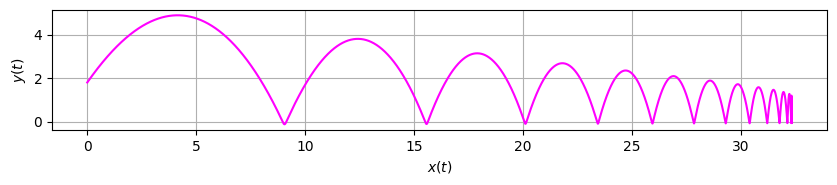

In [6]:
# ============================================================
# a) Pályagörbe – 1,8 m magasról, 55°, 10 m/s, 30 másodperc
#    (nem ütközik semminek → talajmodell nem aktiválódik,
#     csak gravitáció + közegellenállás hat)
# ============================================================

# --- Kezdőfeltételek ---
kezdo_x = 0.0  # kezdeti x pozíció [m]
kezdo_y = 1.8  # kezdeti y pozíció [m] (1.8 m magasról indítjuk)

indulo_sebesseg     = 10.0   # kezdeti sebesség nagysága [m/s]
indulo_szog_fok     = 55.0   # indulási szög (vízszintestől) [°]

# Sebességvektor felbontása x és y komponensre a szög alapján:
kezdo_vx = indulo_sebesseg * np.cos(np.radians(indulo_szog_fok))  # vízszintes sebesség [m/s]
kezdo_vy = indulo_sebesseg * np.sin(np.radians(indulo_szog_fok))  # függőleges sebesség [m/s]

ball_din = num_dinam(2)                     # 2D mozgás (x-y sík)
ball_din.set_time_range(0.0, 30.0, 0.001)    # t ∈ [0, 30] s, dt = 0,001 s


ball_din.set_F_fun(ero_fuggveny)           # erőfüggvény (gravitáció + drag + tolóerő)
ball_din.set_mass_fun(tomeg_fuggveny)      # tömegfüggvény (hajtóanyag-fogyás)
ball_din.set_r0_v0([kezdo_x, kezdo_y],     # kezdeti helyzet:  [0 m, 1.8 m]
                     [kezdo_vx, kezdo_vy]) # kezdeti sebesség: 55°, 10 m/s

# --- Integráció futtatása ---
ball_din.full_dinam_calc()                 # numerikus integráció (pl. RK4)

# --- Pályagörbe megjelenítése ---
ball_din.plot_rcomp()                      # x(t) és y(t) komponensek külön ábrán

In [7]:
# b) Mikor, az eldobás helyétől milyen távol és milyen sebességgel éri el a talajt először a labda?

# --- Az első földetérés indexének meghatározása ---
# arg_eq megkeresi az összes időlépést, ahol y ≈ 0 (talajszint)
# [0] választja ki ezek közül a legkorábbit → első földetérés
ind_ground       = arg_eq(ball_din.r[:, 1], 0.0)   # összes talajszint-átlépés indexei
ind_ground_first = ind_ground[0]                    # első földetérés indexe

print(ind_ground_first)

# --- Segédváltozók az olvashatóságért ---
vabs   = vect_abs(ball_din.v)   # sebességvektor abszolút értéke minden időlépésben [m/s]
x_ball_pos = ball_din.r[:, 0]       # x koordináta idősor [m]
y_ball_pos = ball_din.r[:, 1]       # y koordináta idősor [m]

# --- Eredmények kiírása az első földetérés pillanatában ---
print(f"Első földetérés:")
print(f"  t   = {ball_din.t[ind_ground_first]:.2f} s   (eltelt idő az indítástól)")
print(f"  x   = {x_ball_pos[ind_ground_first]:.2f} m   (vízszintes távolság az eldobás helyétől)")
print(f" |v|  = {vabs[ind_ground_first]:.2f} m/s (becsapódási sebesség nagysága)")

1802
Első földetérés:
  t   = 1.80 s   (eltelt idő az indítástól)
  x   = 8.97 m   (vízszintes távolság az eldobás helyétől)
 |v|  = 10.09 m/s (becsapódási sebesség nagysága)


In [8]:
# ============================================================
# c) Ha tőlünk 3 m-re áll valaki, aki ugrással együtt
#    2,6 m magasra tudja nyújtani a kezét, akkor átrepül-e
#    felette a labda?
# ============================================================

# --- Védő adatai ---
vedo_x = 3.0          # védő távolsága az eldobás helyétől [m]
vedo_y = 2.6   # védő maximális elérési magassága [m]

# --- Labda koordinátái ---
x_ball_pos = ball_din.r[:, 0]   # x koordináta [m]
y_ball_pos = ball_din.r[:, 1]   # y koordináta [m]

# --- Megkeressük, hol halad el a labda x = 3 m-nél ---
ind_x3 = arg_eq(x_ball_pos, vedo_x)[0]

# --- Labda magassága a védő helyén ---
y_x3 = y_ball_pos[ind_x3]

print(f"A labda x = {vedo_x:.1f} m-nél {y_x3:.2f} m magasan jár.")

# --- Döntés ---
if y_x3 > vedo_y:
    print("Átmegy a védő felett.")
else:
    print("Nem megy át a védő felett.")

A labda x = 3.0 m-nél 4.63 m magasan jár.
Átmegy a védő felett.


In [9]:
# ============================================================
# d) Feltéve, hogy a labda egy nagy pályán szabadon pattoghat,
#    keressük meg a pálya első 10 felső holtpontját.
#    Táblázatban adjuk meg ezek magasságát és sebességnagyságát.
# ============================================================

# --- Holtpontok keresése ---
# Magasság szerinti holtpont: v_y = 0,
# vagyis a függőleges sebességkomponens előjelet vált.
ind_holtpont = arg_eq(ball_din.v[:, 1], 0.0)

# --- Alsó holtpontok kiszűrése ---
# Felső holtpontban a gyorsulás lefelé mutat, tehát a_y < 0.
# Alsó holtpontban, pattanás közben, a talaj felfelé gyorsítja a labdát,
# ezért ott a_y > 0.
ind_felsoholtpont = ind_holtpont[ball_din.a[ind_holtpont, 1] < 0]

# --- Első 10 felső holtpont kiválasztása ---
ind_felsoholtpont10 = ind_felsoholtpont[:10]

# --- Sebességnagyság kiszámítása minden időpillanatra ---
vabs = vect_abs(ball_din.v)

# --- Táblázat készítése ---
holtpont_tabla = pd.DataFrame({
    "t [s]": ball_din.t[ind_felsoholtpont10],
    "x [m]": ball_din.r[ind_felsoholtpont10, 0],
    "magasság [m]": ball_din.r[ind_felsoholtpont10, 1],
    "|v| [m/s]": vabs[ind_felsoholtpont10]
})

# --- Szebb megjelenítés ---
holtpont_tabla.round(3)

,t [s],x [m],magasság [m],|v| [m/s]
0,0.777,4.153,4.885,5.054
1,2.706,12.426,3.803,3.616
2,4.432,17.905,3.140,2.767
3,6.016,21.817,2.684,2.187
4,7.491,24.720,2.350,1.757
5,8.878,26.918,2.092,1.417
6,10.193,28.596,1.887,1.136
7,11.448,29.872,1.720,0.897
8,12.649,30.823,1.582,0.687
9,13.805,31.509,1.464,0.499


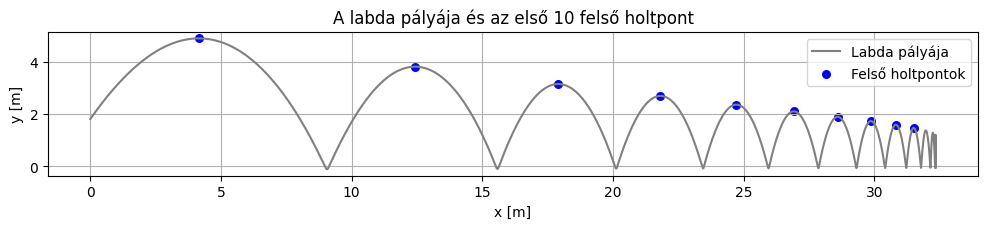

In [10]:
# ============================================================
# e) Készítsen ábrát, melyen a labda pályája szürkével,
#    az előző pontban megtalált felső holtpontok pedig kékkel
#    vannak jelölve!
# ============================================================

# --- Labda pozíció-koordinátái ---
x_ball_pos = ball_din.r[:, 0]   # x koordináta idősor [m]
y_ball_pos = ball_din.r[:, 1]   # y koordináta idősor [m]

# --- Ábra létrehozása ---
fig = plt.figure(figsize=(12, 5))
ax1 = plt.subplot(111)

# --- Pályagörbe kirajzolása szürkével ---
ax1.plot(x_ball_pos, y_ball_pos, color="grey", label="Labda pályája")

# --- Az első 10 felső holtpont jelölése kékkel ---
ax1.scatter(x_ball_pos[ind_felsoholtpont10], y_ball_pos[ind_felsoholtpont10], color="blue", s=30, label="Felső holtpontok")

# --- Ábra formázása ---
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
ax1.set_title("A labda pályája és az első 10 felső holtpont")
ax1.set_aspect(aspect="equal")
ax1.grid()
ax1.legend()

plt.show()

In [11]:
# ============================================================
# f) Ha csupán az eldobás szögét változtathatjuk, akkor
#    milyen szög esetén lesz maximális az ötödik lepattanás
#    távolsága az eldobás helyétől mérve, és mekkora ez a távolság?
# ============================================================

# A feladat lényege:
# - a kezdősebesség nagysága végig ugyanaz marad,
# - csak az eldobás szögét változtatjuk,
# - minden szöghöz lefuttatjuk ugyanazt a pattogó labda szimulációt,
# - minden szögnél megkeressük az 5. földetérést,
# - végül kiválasztjuk azt a szöget, ahol az 5. lepattanás x-koordinátája maximális.


# ============================================================
# Segédfüggvény: adott eldobási szöghöz kiszámítja
# az 5. lepattanás vízszintes távolságát
# ============================================================

def otodik_lepattanas_tavolsag(alpha_deg):
    """
    Egy adott eldobási szög esetén lefuttatja a teljes labdaszimulációt,
    majd visszaadja az 5. lepattanás x-koordinátáját.

    Paraméter:
        alpha_deg : eldobási szög fokban mérve [°]

    Visszatérés:
        Az 5. lepattanás vízszintes távolsága az eldobás helyétől mérve [m].
    """

    # --- Kezdőhelyzet ---
    x0 = 0.0      # kezdeti x pozíció [m]
    y0 = 1.8      # kezdeti y pozíció [m]

    # --- Kezdősebesség ---
    v0 = 10.0     # kezdősebesség nagysága [m/s]

    # A kezdősebességet felbontjuk x és y komponensre.
    # Az alpha_deg az eldobási szög a vízszinteshez képest.
    v0_x = v0 * np.cos(np.radians(alpha_deg))   # kezdősebesség x-komponense [m/s]
    v0_y = v0 * np.sin(np.radians(alpha_deg))   # kezdősebesség y-komponense [m/s]

    # --- Dinamikai objektum létrehozása ---
    ball_din = num_dinam(2)   # 2D mozgás: x és y irány

    # Időtartomány beállítása.
    # Elég hosszú időtartamot kell választani, hogy az 5. lepattanás biztosan beleessen.
    # A kis dt pontosabb szimulációt ad, de lassabb számítást eredményez.
    ball_din.set_time_range(0.0, 30.0, 0.001)

    # Erő- és tömegfüggvény beállítása.
    # Ezeket korábban már létrehoztuk a labda fizikai modelljéhez.
    ball_din.set_F_fun(ero_fuggveny)
    ball_din.set_mass_fun(tomeg_fuggveny)

    # Kezdőhely és kezdősebesség megadása.
    ball_din.set_r0_v0([x0, y0], [v0_x, v0_y])

    # --- Szimuláció futtatása ---
    ball_din.full_dinam_calc()

    # --- A labda koordinátáinak eltárolása olvasható változókba ---
    x_ball_pos = ball_din.r[:, 0]   # x koordináta idősor [m]
    y_ball_pos = ball_din.r[:, 1]   # y koordináta idősor [m]

    # --- Talajérintések megkeresése ---
    # A talaj y = 0 szinten van.
    # Az arg_eq megkeresi azokat az indexeket, ahol a labda y-koordinátája
    # eléri vagy átlépi a 0 értéket.
    ind_ground = arg_eq(y_ball_pos, 0.0)

    # --- Az 5. lepattanás kiválasztása ---
    # Fontos:
    # Egy lepattanás körül a labda kétszer is érintheti / átlépheti a talajszintet:
    #
    #   0. elem: első földetérés, lefelé haladva
    #   1. elem: első felpattanás, felfelé haladva
    #   2. elem: második földetérés
    #   3. elem: második felpattanás
    #   4. elem: harmadik földetérés
    #   5. elem: harmadik felpattanás
    #   6. elem: negyedik földetérés
    #   7. elem: negyedik felpattanás
    #   8. elem: ötödik földetérés
    #
    # Ezért az 5. lepattanás / földetérés indexe az ind_ground tömbben: 8.
    ind_ground_5 = ind_ground[8]

    # Az 5. lepattanás vízszintes távolsága az eldobás helyétől.
    x_ground_5 = x_ball_pos[ind_ground_5]

    return x_ground_5

In [ ]:
# ============================================================
# Szögkeresés: melyik eldobási szögnél lesz maximális
# az 5. lepattanás távolsága?
# ============================================================

# --- Üres listák az eredmények gyűjtéséhez ---
alpha_deg_list = []   # ide kerülnek a kipróbált szögek [°]
x5_list = []          # ide kerülnek az adott szöghöz tartozó 5. lepattanási távolságok [m]

# --- Szögek végigpróbálása ---
# 0° és 90° között próbáljuk ki a szögeket 1°-os lépésközzel.
# Ez egy közelítő optimalizálás: minél kisebb a lépésköz, annál pontosabb,
# de annál lassabb is a számítás.
for alpha_deg in np.arange(0.0, 90.0, 1.0):

    # Az adott szöghöz kiszámítjuk az 5. lepattanás távolságát.
    x5 = otodik_lepattanas_tavolsag(alpha_deg)

    # Az eredményt eltároljuk.
    alpha_deg_list.append(alpha_deg)
    x5_list.append(x5)


# ============================================================
# Maximális távolság kiválasztása
# ============================================================

# A lista maximumának indexét keressük meg.
# Mivel az argmax NumPy-tömbön működik kényelmesen, ezért x5_list-et
# előbb np.array típusú tömbbé alakítjuk.
ind_x5_max = np.array(x5_list).argmax()

# Az optimális szög az az alpha, amelyhez a legnagyobb x5 tartozik.
alpha_x5_max = alpha_deg_list[ind_x5_max]

# A maximális 5. lepattanási távolság.
x5_max = x5_list[ind_x5_max]


# ============================================================
# Eredmény kiírása
# ============================================================

print(f"Az 5. lepattanás alpha = {alpha_x5_max:.1f}° esetén lesz a legtávolabb.")
print(f"Ez a távolság: x = {x5_max:.2f} m.")



Az 5. lepattanás alpha = 27.0° esetén lesz a legtávolabb.
Ez a távolság: x = 32.86 m.


[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0), np.float64(24.0), np.float64(25.0), np.float64(26.0), np.float64(27.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(31.0), np.float64(32.0), np.float64(33.0), np.float64(34.0), np.float64(35.0), np.float64(36.0), np.float64(37.0), np.float64(38.0), np.float64(39.0), np.float64(40.0), np.float64(41.0), np.float64(42.0), np.float64(43.0), np.float64(44.0), np.float64(45.0), np.float64(46.0), np.float64(47.0), np.float64(48.0), np.float64(49.0), np.float64(50.0), np.float64(51.0), np.float64(52.0), np.float64(53.0), np.float64(54.0), np.float64(55.0), n

ValueError: x and y must have same first dimension, but have shapes (90,) and (1,)

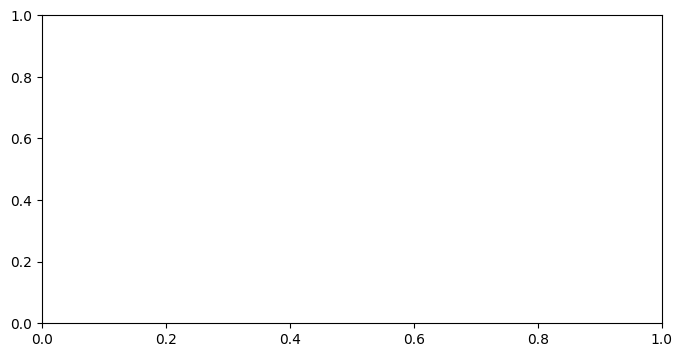

In [ ]:
x5 = np.array(x5_list)  # lista → NumPy tömb
alpha_deg = np.array(alpha_deg_list)

i = x5.argmax()

plt.figure(figsize=(8, 4))
plt.plot(alpha_deg, x5)
plt.scatter(alpha_deg[i], x5[i], color='red', zorder=3,
            label=f'maximum: {alpha_deg[i]:.1f}°, {x5[i]:.2f} m')
plt.xlabel('eldobási szög (fok)')
plt.ylabel('5. lepattanás távolsága (m)')
plt.legend()
plt.grid()
plt.show()